In [1]:
import os

from transformers_sae.ops import load_validations

VALIDATION_BASE_PATH = os.path.join(
    os.environ["HF_BUCKET_LOCAL"], "validations/gemma_2_2b"
)

all_validations = {
    name: load_validations(validation_dir)
    for name in os.listdir(VALIDATION_BASE_PATH)
    if os.path.isdir(validation_dir := os.path.join(VALIDATION_BASE_PATH, name))
}

num_layers = 0
for name, validations in all_validations.items():
    num_layers = max(validations.keys())
    break

layers = list(range(0, num_layers))

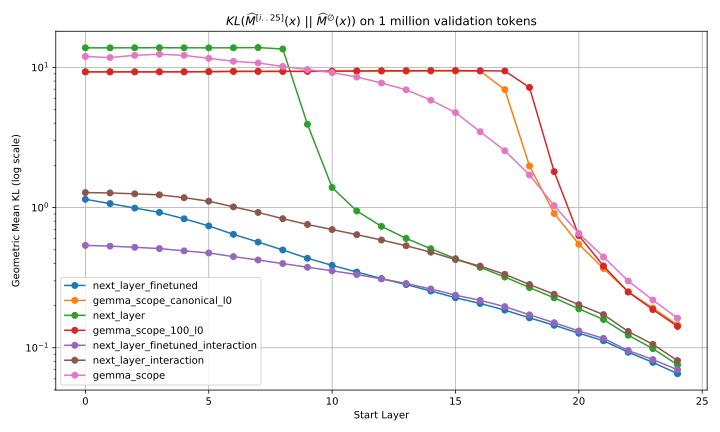

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from transformers_sae.ops import current_plot_to_svg

def compute_geom_kl(validations):
    return {
        layer: np.exp(
            np.mean(np.log(np.clip(v.layer_results[num_layers + 1].kl, min=1e-9)))
        ).item()
        for layer, v in validations.items()
    }


all_kl = {
    name: compute_geom_kl(validations) for name, validations in all_validations.items()
}

plt.figure(figsize=(10, 6))

for name, kl_dict in all_kl.items():
    plt.plot(
        layers,
        [kl_dict[layer] if layer in kl_dict else np.nan for layer in layers],
        marker="o",
        label=name,
    )

plt.xlabel("Start Layer")
plt.ylabel("Geometric Mean KL (log scale)")
plt.yscale("log")
plt.title("$KL(\\widehat{{M}}^{{[i..25]}}(x)\\ ||\\ \\widehat{{M}}^{{\\emptyset}}(x))$ on 1 million validation tokens")
plt.grid(True)
plt.legend()
plt.tight_layout()

current_plot_to_svg("full_replacement_kl")


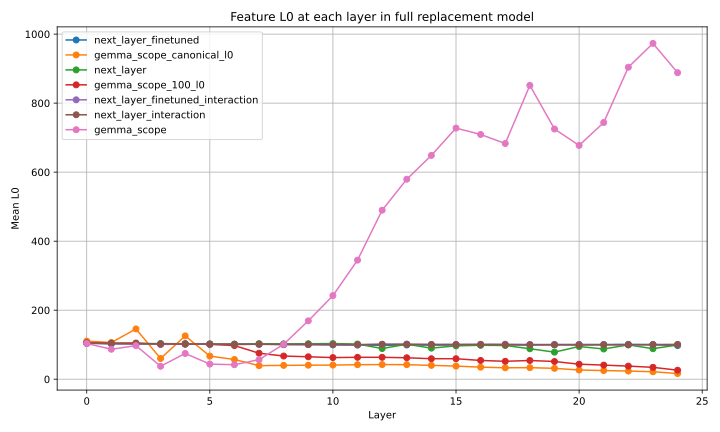

In [9]:
def full_replacement_l0(validations):
    return {
        layer: np.mean(v.l0)
        for layer, v in validations.layer_results.items()
        if v.l0 is not None
    }


all_l0 = {
    name: full_replacement_l0(validations[min(validations.keys())])
    for name, validations in all_validations.items()
}

plt.figure(figsize=(10, 6))

for name, l0_dict in all_l0.items():
    plt.plot(
        layers,
        [l0_dict[layer] if layer in l0_dict else np.nan for layer in layers],
        marker="o",
        label=name,
    )

plt.xlabel("Layer")
plt.ylabel("Mean L0")
plt.title("Feature L0 at each layer in full replacement model")
plt.grid(True)
plt.legend()
plt.tight_layout()

current_plot_to_svg("full_replacement_l0")

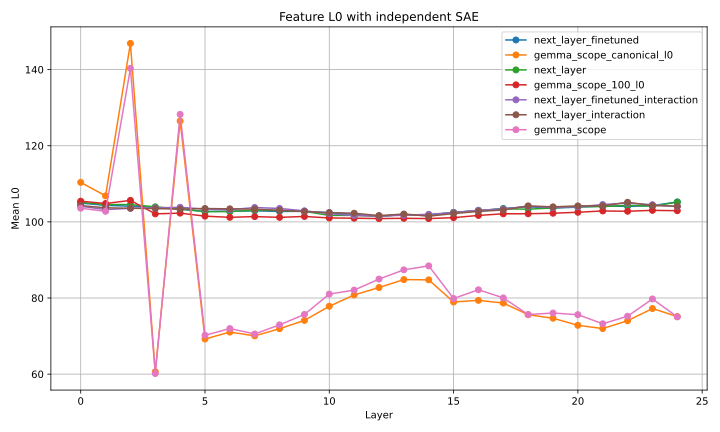

In [4]:
plt.figure(figsize=(10, 6))

for name, validation_dict in all_validations.items():
    plt.plot(
        layers,
        [
            np.mean(validation_dict[layer].layer_results[layer].l0)
            if layer in validation_dict
            else np.nan
            for layer in layers
        ],
        marker="o",
        label=name,
    )

plt.xlabel("Layer")
plt.ylabel("Mean L0")
plt.title("Feature L0 with independent SAE")
plt.grid(True)
plt.legend()
plt.tight_layout()

current_plot_to_svg("independent_sae_l0")

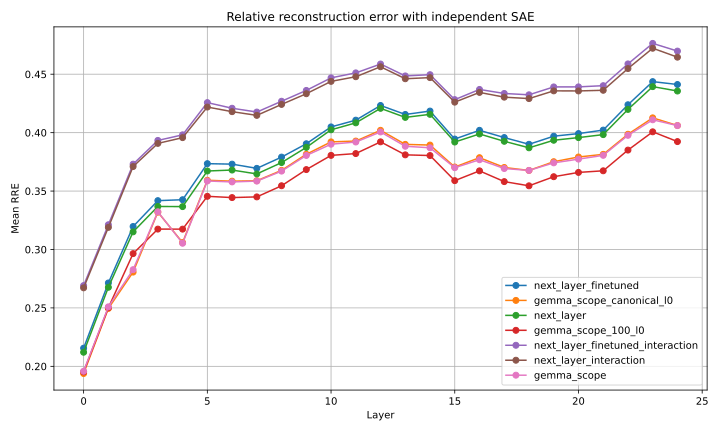

In [5]:
plt.figure(figsize=(10, 6))

for name, validation_dict in all_validations.items():
    plt.plot(
        layers,
        [
            np.mean(validation_dict[layer].layer_results[layer].rre)
            if layer in validation_dict
            else np.nan
            for layer in layers
        ],
        marker="o",
        label=name,
    )

plt.xlabel("Layer")
plt.ylabel("Mean RRE")
plt.title("Relative reconstruction error with independent SAE")
plt.grid(True)
plt.legend()
plt.tight_layout()

current_plot_to_svg("independent_sae_rre")

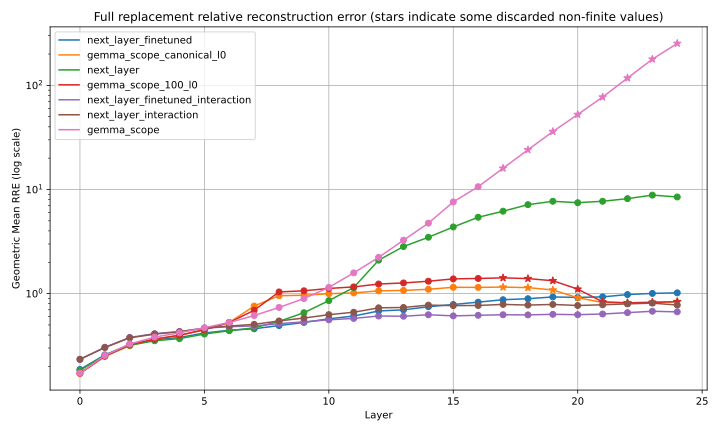

In [8]:
def compute_geom_rre(validations):
    return {
        layer: (
            np.exp(np.mean(np.log(v.rre[np.isfinite(v.rre)]))).item(),
            np.sum(~np.isfinite(v.rre)) / len(validations.position_ids),
        )
        for layer, v in validations.layer_results.items()
        if v.rre is not None
    }


all_rre = {
    name: compute_geom_rre(validations[min(validations.keys())])
    for name, validations in all_validations.items()
}

plt.figure(figsize=(10, 6))

for name, rre_dict in all_rre.items():
    y_values = [rre_dict[layer][0] if layer in rre_dict else np.nan for layer in layers]
    markers = ["*" if layer in rre_dict and rre_dict[layer][1] > 0 else "o" for layer in layers]
    
    # Plot the line without markers first
    line, = plt.plot(layers, y_values, label=name)
    color = line.get_color()
    
    # Plot each point with appropriate marker
    for layer, y, marker in zip(layers, y_values, markers):
        plt.plot(layer, y, marker=marker, color=color, markersize=8 if marker == "*" else 6)

plt.xlabel("Layer")
plt.ylabel("Geometric Mean RRE (log scale)")
plt.yscale("log")
plt.title(
    "Full replacement relative reconstruction error (stars indicate some discarded non-finite values)"
)
plt.grid(True)
plt.legend()
plt.tight_layout()

current_plot_to_svg("full_replacement_rre")